In [1]:
# =============================================================================
# 1. Imports y configuración
# =============================================================================
 
import re
import numpy as np
import evaluate
import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
# ── Modelo a usar ─────────────────────────────────────────────────────────────
# Cambia esta línea para comparar modelos distintos:
#
#   "distilbert-base-uncased"                          ~66M  params  ← rápido
#   "bert-base-uncased"                                ~110M params
#   "roberta-base"                                     ~125M params
#   "cardiffnlp/twitter-roberta-base-sentiment-latest" ~125M + dominio tweets
#   "cardiffnlp/bertweet-base-sentiment-analysis"      SOTA TweetEval
 
MODEL_NAME = "distilbert-base-uncased"
 
# ── Hiperparámetros ───────────────────────────────────────────────────────────
MAX_LEN    = 128
BATCH_SIZE = 32
EPOCHS     = 3
LR         = 2e-5
 
LABEL_NAMES = ["negative", "neutral", "positive"]
NUM_CLASSES = len(LABEL_NAMES)
 
print(f"Modelo : {MODEL_NAME}")
print(f"Device : {'cuda' if torch.cuda.is_available() else 'cpu'}")


Modelo : distilbert-base-uncased
Device : cuda


In [3]:
# =============================================================================
# 2. Cargar dataset
# =============================================================================
# load_dataset devuelve un DatasetDict con splits "train", "validation", "test".
# Cada split es un Dataset de HuggingFace con columnas "text" y "label".
 
raw_datasets = load_dataset("tweet_eval", "sentiment")
print(raw_datasets)
 
# Inspeccionar un ejemplo
print("\nEjemplo de train:")
print(raw_datasets["train"][0])
 
# Distribución de clases
from collections import Counter
label_counts = Counter(raw_datasets["train"]["label"])
print("\nDistribución de clases (train):")
for idx, name in enumerate(LABEL_NAMES):
    print(f"  {idx} — {name:10s}: {label_counts[idx]:,}")


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

Ejemplo de train:
{'text': '"QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"', 'label': 2}

Distribución de clases (train):
  0 — negative  : 7,093
  1 — neutral   : 20,673
  2 — positive  : 17,849


In [4]:
# =============================================================================
# 3. Preprocesamiento y tokenización
# =============================================================================
# AutoTokenizer carga el tokenizer correcto para cualquier modelo.
# Para BERT: WordPiece  |  Para RoBERTa/DistilBERT: BPE
 
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
 
print(f"\nTokenizer : {type(tokenizer).__name__}")
print(f"Vocab size: {tokenizer.vocab_size:,}")
 
# Ejemplo de tokenización
ejemplo = "I love PyTorch so much!! 🔥 @user check this out http://example.com"
tokens  = tokenizer(ejemplo, truncation=True, max_length=MAX_LEN)
print(f"\nTexto    : {ejemplo}")
print(f"input_ids: {tokens['input_ids']}")
print(f"tokens   : {tokenizer.convert_ids_to_tokens(tokens['input_ids'])}")
 
 
def clean_tweet(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "[URL]", text)
    text = re.sub(r"@\w+",           "[USER]", text)
    text = re.sub(r"#(\w+)",         r"\1", text)
    text = re.sub(r"\s+",            " ", text).strip()
    return text
 
 
def tokenize_function(batch):
    """
    Recibe un batch de ejemplos (dict de listas) y devuelve
    los campos que el modelo necesita: input_ids, attention_mask,
    y token_type_ids (solo si el modelo los usa).
 
    DataCollatorWithPadding se encarga del padding dinámico,
    así que aquí solo truncamos.
    """
    texts = [clean_tweet(t) for t in batch["text"]]
    return tokenizer(texts, truncation=True, max_length=MAX_LEN)
 
 
# .map() aplica la función sobre todo el dataset de forma eficiente (batched).
# remove_columns="text" elimina la columna original que el modelo no necesita.
tokenized_datasets = raw_datasets.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"],
)
 
# El Trainer espera la columna de etiquetas con el nombre "labels"
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
 
# Indicamos que los tensores son de PyTorch
tokenized_datasets.set_format("torch")
 
print("\nDataset tokenizado:")
print(tokenized_datasets)
print("\nColumnas:", tokenized_datasets["train"].column_names)
print("Ejemplo :", tokenized_datasets["train"][0])



Tokenizer : BertTokenizer
Vocab size: 30,522

Texto    : I love PyTorch so much!! 🔥 @user check this out http://example.com
input_ids: [101, 1045, 2293, 1052, 22123, 2953, 2818, 2061, 2172, 999, 999, 100, 1030, 5310, 4638, 2023, 2041, 8299, 1024, 1013, 1013, 2742, 1012, 4012, 102]
tokens   : ['[CLS]', 'i', 'love', 'p', '##yt', '##or', '##ch', 'so', 'much', '!', '!', '[UNK]', '@', 'user', 'check', 'this', 'out', 'http', ':', '/', '/', 'example', '.', 'com', '[SEP]']


Map:   0%|          | 0/45615 [00:00<?, ? examples/s]

Map:   0%|          | 0/12284 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]


Dataset tokenizado:
DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

Columnas: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']
Ejemplo : {'labels': tensor(2), 'input_ids': tensor([  101,  1000,  1053,  2102,  1031,  5310,  1033,  1999,  1996,  2434,
         4433,  1997,  1996,  5504,  2338,  1010,  2128,  7606, 11320,  8091,
         5175,  1996,  2645,  1997, 27589, 18367,  2015,  1012,  3407, 17706,
         2705, 10259, 28578,  2271,  7630,  8091,  1000,   102]), 'token_type_ids': tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), 

In [5]:
# =============================================================================
# 4. Data collator
# =============================================================================
# DataCollatorWithPadding hace padding dinámico: cada batch se padea hasta
# el largo del ejemplo más largo del batch (no hasta MAX_LEN fijo).
# Esto es más eficiente que padding estático.
 
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
 
# =============================================================================
# 5. Modelo
# =============================================================================
# AutoModelForSequenceClassification añade automáticamente una capa de
# clasificación encima del encoder preentrenado.
#
# id2label / label2id le dice al modelo cómo mapear índices a nombres de clase.
# ignore_mismatched_sizes=True permite cargar checkpoints que ya tienen
# una head de clasificación con diferente número de clases.
 
id2label = {i: name for i, name in enumerate(LABEL_NAMES)}
label2id = {name: i for i, name in enumerate(LABEL_NAMES)}
 
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)
 
# Resumen de parámetros
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModelo      : {type(model).__name__}")
print(f"Total params: {total:,}")
print(f"Trainable   : {trainable:,}")


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Modelo      : DistilBertForSequenceClassification
Total params: 66,955,779
Trainable   : 66,955,779


In [6]:
# =============================================================================
# 6. Métricas
# =============================================================================
# compute_metrics recibe un EvalPrediction (logits + labels) y devuelve
# un dict de métricas que el Trainer loguea en cada evaluación.
 
metric_acc = evaluate.load("accuracy")
metric_f1  = evaluate.load("f1")
 
 
def compute_metrics(eval_pred):
    """
    eval_pred.predictions : logits  (N, num_classes)
    eval_pred.label_ids   : labels  (N,)
    """
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
 
    acc = metric_acc.compute(predictions=preds, references=labels)["accuracy"]
    f1  = metric_f1.compute(predictions=preds, references=labels,
                            average="macro")["f1"]
    return {"accuracy": acc, "f1_macro": f1}


In [7]:
# =============================================================================
# 7. TrainingArguments
# =============================================================================
# TrainingArguments centraliza todos los hiperparámetros de entrenamiento.
# Documentación completa: https://huggingface.co/docs/transformers/main_classes/trainer#transformers.TrainingArguments
 
safe_name = MODEL_NAME.replace("/", "__")   # para nombres de directorio
 
training_args = TrainingArguments(
    # ── Directorios ────────────────────────────────────────────────────────
    output_dir          = f"checkpoints/{safe_name}",   # donde se guardan los checkpoints
    logging_dir         = f"runs/{safe_name}",          # TensorBoard
 
    # ── Epochs y batch ─────────────────────────────────────────────────────
    num_train_epochs              = EPOCHS,
    per_device_train_batch_size   = BATCH_SIZE,
    per_device_eval_batch_size    = BATCH_SIZE,
 
    # ── Optimizador ────────────────────────────────────────────────────────
    learning_rate   = LR,
    weight_decay    = 0.01,         # L2 regularization en AdamW
    warmup_ratio    = 0.1,          # 10% de pasos con lr creciente
    lr_scheduler_type = "linear",   # decay lineal después del warmup
 
    # ── Evaluación y checkpoints ───────────────────────────────────────────
    eval_strategy           = "epoch",      # evalúa al final de cada época
    save_strategy           = "epoch",      # guarda checkpoint cada época
    load_best_model_at_end  = True,         # recarga el mejor al terminar
    metric_for_best_model   = "f1_macro",   # métrica para "mejor"
    greater_is_better       = True,
 
    # ── Logging ────────────────────────────────────────────────────────────
    logging_steps   = 50,           # loguea cada 50 pasos
    report_to       = "tensorboard",
 
    # ── Precisión ──────────────────────────────────────────────────────────
    fp16 = torch.cuda.is_available(),   # mixed precision en GPU
 
    seed = 42,
)
 
print("\nTrainingArguments configurado:")
print(f"  output_dir  : {training_args.output_dir}")
print(f"  epochs      : {training_args.num_train_epochs}")
print(f"  batch_size  : {training_args.per_device_train_batch_size}")
print(f"  lr          : {training_args.learning_rate}")
print(f"  fp16        : {training_args.fp16}")


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.



TrainingArguments configurado:
  output_dir  : checkpoints/distilbert-base-uncased
  epochs      : 3
  batch_size  : 32
  lr          : 2e-05
  fp16        : True


In [8]:
# =============================================================================
# 8. Trainer
# =============================================================================
# El Trainer encapsula el loop de entrenamiento completo:
#   - forward / backward / optimizer step
#   - evaluación periódica
#   - guardado de checkpoints
#   - logging a TensorBoard
#
# Sus argumentos principales:
#   model           — el modelo a entrenar
#   args            — TrainingArguments
#   train_dataset   — dataset de entrenamiento (tokenizado)
#   eval_dataset    — dataset de validación
#   processing_class — tokenizer (para padding dinámico)
#   data_collator   — cómo armar cada batch
#   compute_metrics — función de métricas
 
trainer = Trainer(
    model            = model,
    args             = training_args,
    train_dataset    = tokenized_datasets["train"],
    eval_dataset     = tokenized_datasets["validation"],
    processing_class = tokenizer,
    data_collator    = data_collator,
    compute_metrics  = compute_metrics,
)
 


In [9]:
# =============================================================================
# 9. Entrenamiento
# =============================================================================
 
print(f"\nIniciando entrenamiento — {MODEL_NAME}")
train_result = trainer.train()
 
print("\nResultados de entrenamiento:")
print(f"  Pasos totales : {train_result.global_step}")
print(f"  Train loss    : {train_result.training_loss:.4f}")
print(f"  Tiempo total  : {train_result.metrics['train_runtime']:.1f}s")
 
# =============================================================================
# 10. Evaluación en validación
# =============================================================================
 
val_metrics = trainer.evaluate()
print("\nMétricas en validación:")
for k, v in val_metrics.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")



Iniciando entrenamiento — distilbert-base-uncased


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.608472,0.632797,0.712000,0.688512
2,0.535419,0.621406,0.736000,0.714029
3,0.426947,0.644225,0.745500,0.729669


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Resultados de entrenamiento:
  Pasos totales : 4278
  Train loss    : 0.5564
  Tiempo total  : 268.7s


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.426947,0.644225,3,0.745500,0.729669



Métricas en validación:
  eval_loss: 0.6442
  eval_accuracy: 0.7455
  eval_f1_macro: 0.7297


In [10]:
# =============================================================================
# 11. Evaluación en test
# =============================================================================
# trainer.predict() devuelve un NamedTuple con:
#   .predictions  — logits (N, num_classes)
#   .label_ids    — etiquetas reales (N,)
#   .metrics      — dict con loss y métricas
 
test_output = trainer.predict(tokenized_datasets["test"])
 
test_preds  = np.argmax(test_output.predictions, axis=-1)
test_labels = test_output.label_ids
 
print("\nMétricas en test:")
for k, v in test_output.metrics.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")



Métricas en test:
  test_loss: 0.7534
  test_accuracy: 0.6859
  test_f1_macro: 0.6846
  test_runtime: 6.1755
  test_samples_per_second: 1989.1440
  test_steps_per_second: 62.1810



  distilbert-base-uncased
              precision    recall  f1-score   support

    negative     0.6898    0.7210    0.7051      3972
     neutral     0.7074    0.6544    0.6798      5937
    positive     0.6352    0.7061    0.6688      2375

    accuracy                         0.6859     12284
   macro avg     0.6775    0.6938    0.6846     12284
weighted avg     0.6877    0.6859    0.6859     12284



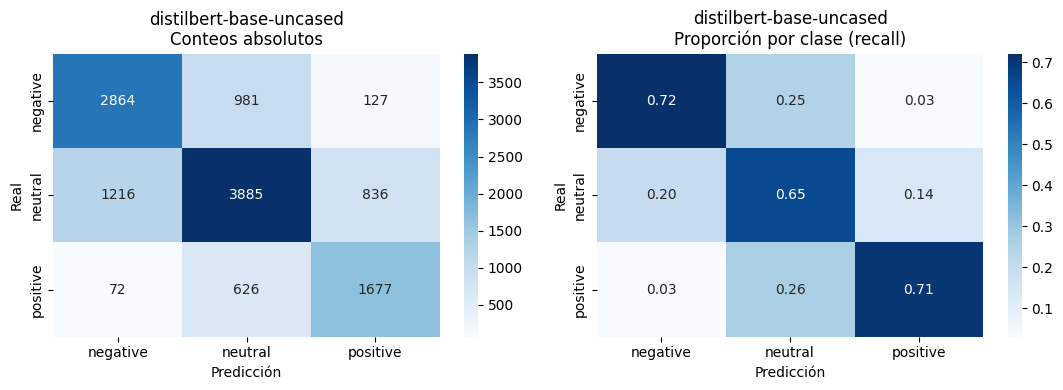

In [11]:
# =============================================================================
# 12. Reporte detallado y matriz de confusión
# =============================================================================
 
print(f"\n{'='*55}")
print(f"  {MODEL_NAME}")
print(f"{'='*55}")
print(classification_report(test_labels, test_preds,
                             target_names=LABEL_NAMES, digits=4))
 
cm      = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
 
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, data, fmt, title in zip(
    axes, [cm, cm_norm], ["d", ".2f"],
    ["Conteos absolutos", "Proporción por clase (recall)"],
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=ax)
    ax.set_xlabel("Predicción"); ax.set_ylabel("Real")
    ax.set_title(f"{MODEL_NAME.split('/')[-1]}\n{title}")
plt.tight_layout()
plt.show()


In [12]:
# =============================================================================
# 13. Guardar el modelo final  (opcional)
# =============================================================================
# trainer.save_model() guarda el modelo y el tokenizer en un directorio.
# Luego se puede cargar con from_pretrained() desde ese directorio.
 
trainer.save_model(f"saved_models/{safe_name}")
tokenizer.save_pretrained(f"saved_models/{safe_name}")
print(f"\nModelo guardado en: saved_models/{safe_name}")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Modelo guardado en: saved_models/distilbert-base-uncased


In [ ]:
# Para cargar después:
# model     = AutoModelForSequenceClassification.from_pretrained("saved_models/...")
# tokenizer = AutoTokenizer.from_pretrained("saved_models/...")
